# Bank Churn — 01: Exploratory Data Analysis

**Series:** 01 EDA (this notebook) → 02 Logistic → 03 XGBoost → 04 LightGBM →
05 Decision analysis & business proposals → 06 Causal analysis (propensity scores).

This notebook does one job: establish the *structure* of the data, because every
modelling and business decision downstream is justified by what is found here.

## 1. Setup & data acquisition

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
print(f"Shape: {df.shape}")
df.head()

Found cached file: data/Churn_Modelling.csv
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data validation

In [2]:
assert df.shape == (10_000, 14), "Unexpected shape"
assert df.isnull().sum().sum() == 0, "Missing values present"
assert df["CustomerId"].is_unique, "Duplicate customers"
assert set(df["Exited"].unique()) == {0, 1}, "Target is not binary"

churn_rate = df["Exited"].mean()
print(f"All integrity checks passed. Base churn rate: {churn_rate:.2%}")

df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.describe().T.round(2)

All integrity checks passed. Base churn rate: 20.37%


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
Exited,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


## 3. Univariate view — every feature against the target

### 3.1 Numeric features: distributions by churn status

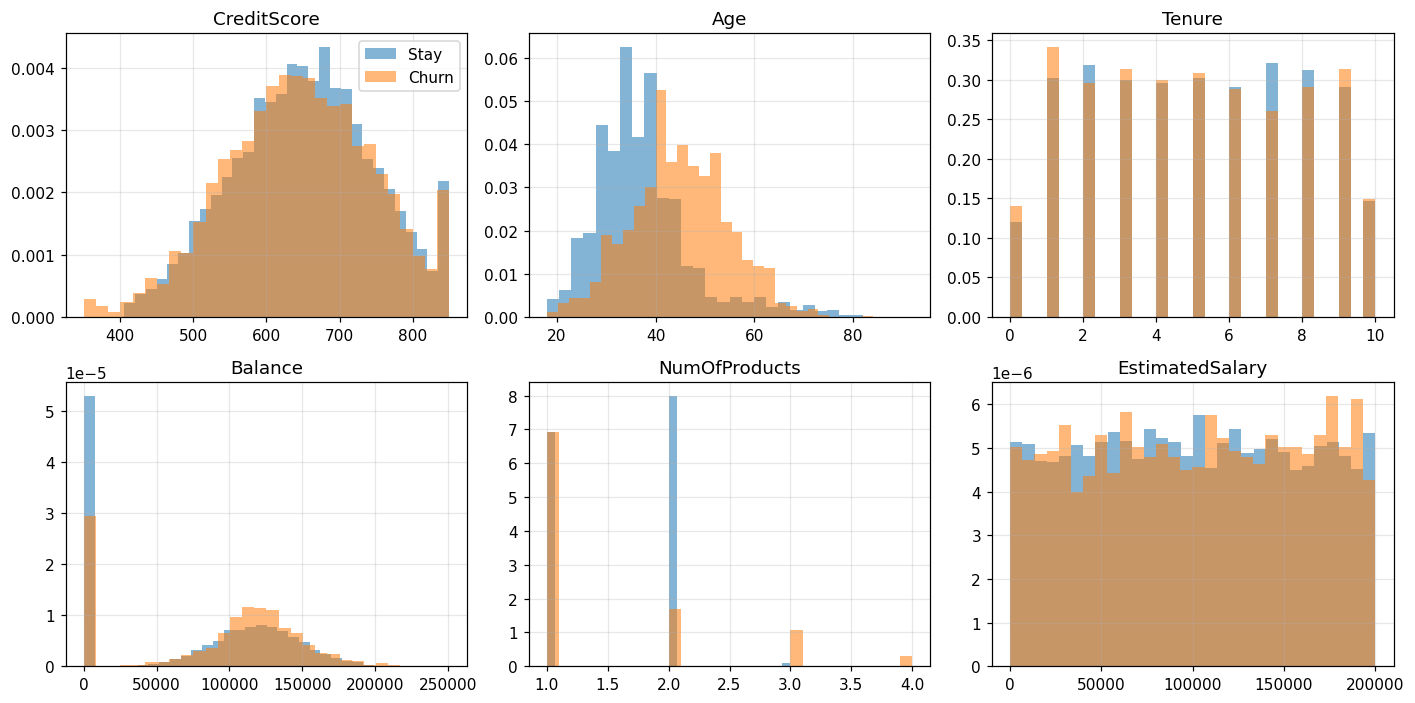

In [3]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.ravel(), num_cols):
    for label, name in [(0, "Stay"), (1, "Churn")]:
        ax.hist(df[df["Exited"] == label][col], bins=30, alpha=0.55, density=True, label=name)
    ax.set_title(col)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

Age separates the classes visibly; Balance is bimodal (a large zero-spike plus a
roughly normal component around 100–140k); CreditScore, Tenure and EstimatedSalary are
nearly indistinguishable between classes — candidates for low model importance.

### 3.2 Categorical / binary features: churn rates

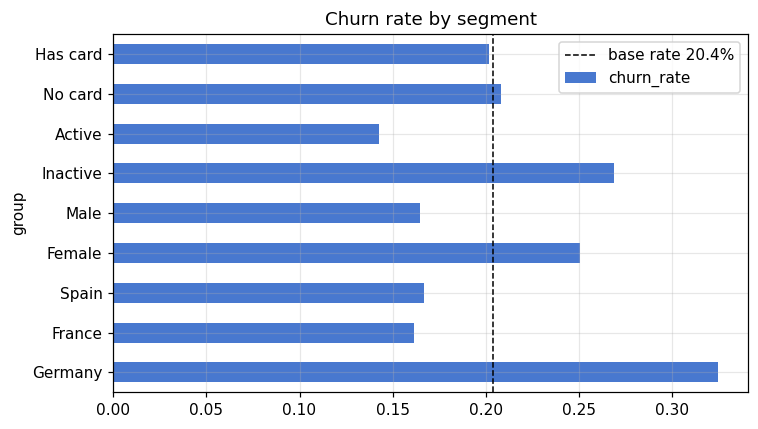

   group  churn_rate
 Germany       0.324
  France       0.162
   Spain       0.167
  Female       0.251
    Male       0.165
Inactive       0.269
  Active       0.143
 No card       0.208
Has card       0.202


In [4]:
cat_summary = pd.DataFrame({
    "group": ["Germany", "France", "Spain", "Female", "Male",
              "Inactive", "Active", "No card", "Has card"],
    "churn_rate": [
        df[df.Geography == "Germany"].Exited.mean(),
        df[df.Geography == "France"].Exited.mean(),
        df[df.Geography == "Spain"].Exited.mean(),
        df[df.Gender == "Female"].Exited.mean(),
        df[df.Gender == "Male"].Exited.mean(),
        df[df.IsActiveMember == 0].Exited.mean(),
        df[df.IsActiveMember == 1].Exited.mean(),
        df[df.HasCrCard == 0].Exited.mean(),
        df[df.HasCrCard == 1].Exited.mean(),
    ],
})
ax = cat_summary.set_index("group")["churn_rate"].plot.barh(figsize=(7, 4), color="#4878CF")
ax.axvline(churn_rate, ls="--", c="k", lw=1, label=f"base rate {churn_rate:.1%}")
ax.set_title("Churn rate by segment")
ax.legend()
plt.tight_layout()
plt.show()
print(cat_summary.round(3).to_string(index=False))

Germany (32.4%), inactivity (26.9%) and being female (25.1%) sit clearly above base
rate; the credit-card flag is inert (28.2k vs 29.5k basis points — noise).

## 4. The three structural findings

### 4.1 Geography × Balance entanglement

            mean  count  zero_balance_share
Geography                                  
France     0.162   5014               0.482
Germany    0.324   2509               0.000
Spain      0.167   2477               0.484


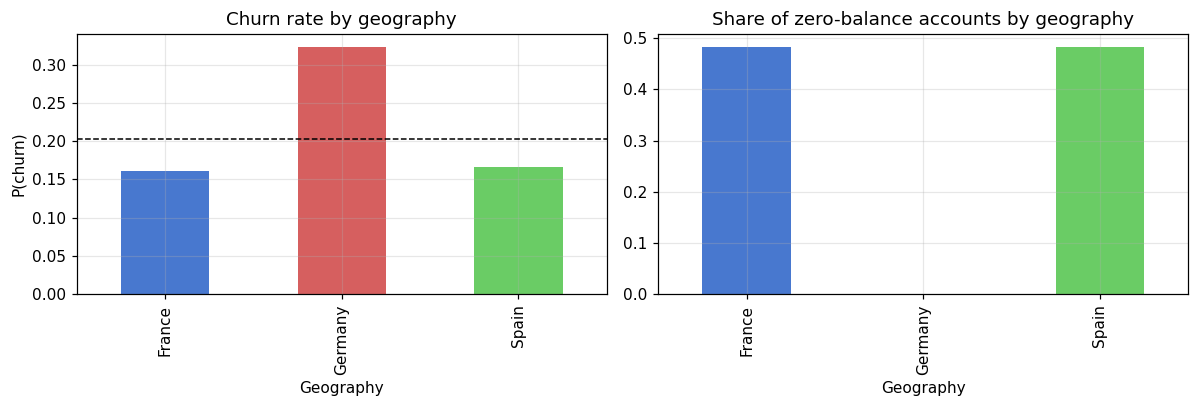

In [5]:
geo = df.groupby("Geography")["Exited"].agg(["mean", "count"])
geo["zero_balance_share"] = df.groupby("Geography")["Balance"].apply(lambda s: (s == 0).mean())
print(geo.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
geo["mean"].plot.bar(ax=axes[0], color=["#4878CF", "#D65F5F", "#6ACC65"])
axes[0].axhline(churn_rate, ls="--", c="k", lw=1)
axes[0].set_title("Churn rate by geography")
axes[0].set_ylabel("P(churn)")

geo["zero_balance_share"].plot.bar(ax=axes[1], color=["#4878CF", "#D65F5F", "#6ACC65"])
axes[1].set_title("Share of zero-balance accounts by geography")
plt.tight_layout()
plt.show()

**Finding 1:** German customers churn at 2× the rate of France/Spain — and Germany has
essentially **no zero-balance accounts** while France/Spain have ~45–50%. Balance and
Geography are structurally entangled: a raw balance coefficient would partly proxy for
being German. Modelling consequence: an explicit `zero_balance` flag plus a
Germany × Balance interaction.

### 4.2 NumOfProducts: U-shaped risk

                mean  count
NumOfProducts              
1              0.277   5084
2              0.076   4590
3              0.827    266
4              1.000     60


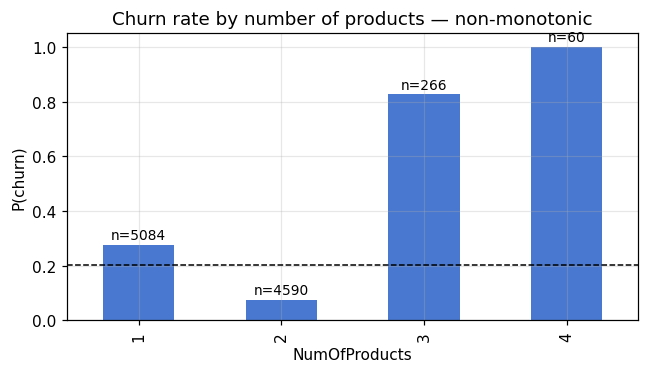

In [6]:
prod = df.groupby("NumOfProducts")["Exited"].agg(["mean", "count"])
print(prod.round(3))

ax = prod["mean"].plot.bar(figsize=(6, 3.5), color="#4878CF")
ax.axhline(churn_rate, ls="--", c="k", lw=1)
for i, (rate, n) in enumerate(zip(prod["mean"], prod["count"])):
    ax.text(i, rate + 0.02, f"n={n}", ha="center", fontsize=9)
ax.set_title("Churn rate by number of products — non-monotonic")
ax.set_ylabel("P(churn)")
plt.tight_layout()
plt.show()

**Finding 2:** Two products is the safest state (7.6%); three or four products means
near-certain churn (82.7% / 100%, though on small n = 266/60). Not a monotone
"engagement = loyalty" story — plausibly cross-sold products masking dissatisfaction.
Modelling consequence: `NumOfProducts` must enter linear models as a **categorical**;
a single coefficient cannot represent a U-shape.

### 4.3 Age: the strongest driver, non-linearly

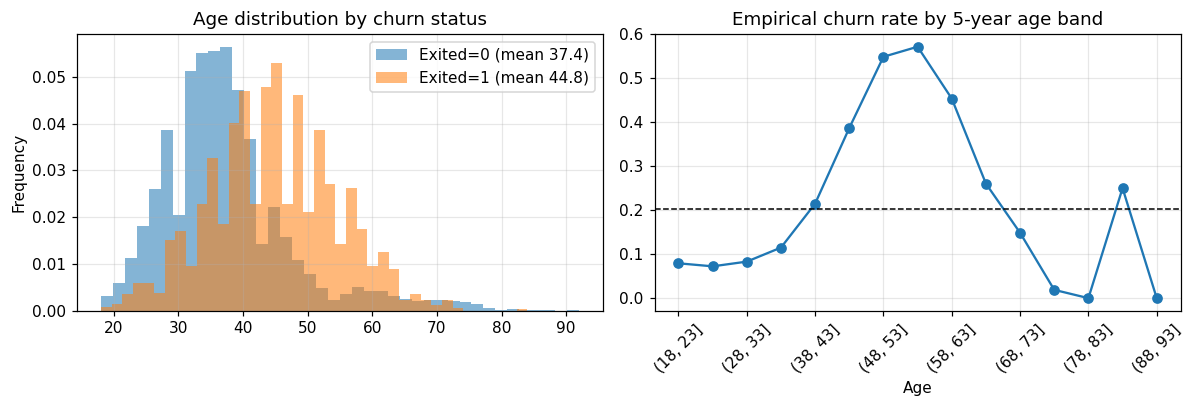

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for label, grp in df.groupby("Exited"):
    grp["Age"].plot.hist(bins=40, ax=axes[0], alpha=0.55, density=True,
                         label=f"Exited={label} (mean {grp['Age'].mean():.1f})")
axes[0].set_title("Age distribution by churn status")
axes[0].legend()

age_bins = pd.cut(df["Age"], bins=range(18, 95, 5))
df.groupby(age_bins)["Exited"].mean().plot(ax=axes[1], marker="o")
axes[1].axhline(churn_rate, ls="--", c="k", lw=1)
axes[1].set_title("Empirical churn rate by 5-year age band")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Finding 3:** Churners average 44.8 vs 37.4 years; risk climbs steeply through the 40s,
peaks near 50–60, then declines. A second strong non-linearity favoring tree models.

## 5. Interactions & correlation structure

Churn rate: Geography × Activity
           Inactive  Active
Geography                  
France        0.211   0.115
Germany       0.411   0.237
Spain         0.233   0.107 

Churn rate: Age band × Activity
          Inactive  Active
Age                       
(18, 35]     0.109   0.059
(35, 45]     0.242   0.146
(45, 55]     0.636   0.372
(55, 92]     0.891   0.180


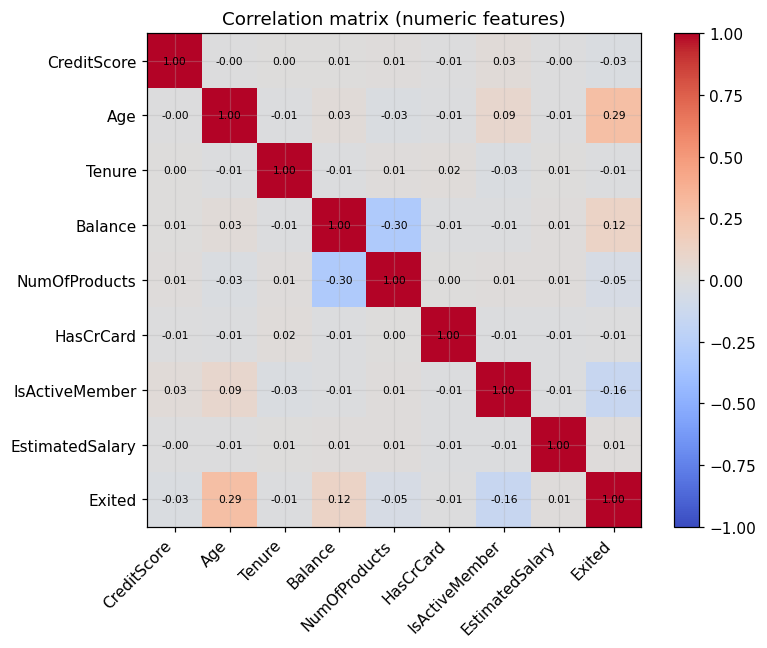

In [8]:
pivot = df.pivot_table(values="Exited", index="Geography", columns="IsActiveMember",
                       aggfunc="mean")
pivot.columns = ["Inactive", "Active"]
print("Churn rate: Geography × Activity")
print(pivot.round(3), "\n")

pivot2 = df.pivot_table(values="Exited", index=pd.cut(df["Age"], [18, 35, 45, 55, 92]),
                        columns="IsActiveMember", aggfunc="mean")
pivot2.columns = ["Inactive", "Active"]
print("Churn rate: Age band × Activity")
print(pivot2.round(3))

corr = df.select_dtypes("number").corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

Two things worth noting: (i) inactive seniors are the single worst cell (inactivity
roughly doubles churn *within every* age band and geography — motivation for the
`inactive_senior` feature and for the causal question in notebook 06); (ii) pairwise
correlations are weak everywhere except Balance–NumOfProducts (−0.30), confirming that
the signal lives in non-linearities and interactions rather than linear correlation.

## 6. Summary — what the models must handle

| Structure found | Modelling consequence |
|---|---|
| Germany 2× churn, zero-balance only outside Germany | `zero_balance` flag + Geography×Balance interaction |
| U-shaped product effect | `NumOfProducts` categorical in linear models |
| Non-linear age effect | favors tree models; linear model will hit a ceiling |
| Inactivity doubles churn within every segment | `inactive_senior` feature; causal question → nb 06 |
| CreditScore / Tenure / Salary flat | keep but expect low importance |

**Next:** notebook 02 — the tuned logistic baseline that every tree model must beat.